# Feature Availability and Inclusion Review

This notebook explains which inputs are included in the monthly water-demand forecasting dataset, which raw fields are excluded, and why. It is designed to make the feature decisions easy to review and present.

The central rule is simple: a feature may be used only if it would be known before the month being predicted.

## 1. What this review does

We are not choosing features only because they have a high correlation. Instead, we first check whether each input is available at prediction time, then document how it is transformed. This prevents future information from entering the model accidentally.

The final output contains calendar features, historical demand features, historical weather and system-state features, and historical demographic features.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
for candidate in (PROJECT_ROOT, PROJECT_ROOT.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate.resolve()
        break
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError('Could not locate the project root containing src/.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.phase4_data_loader import load_dnh_total_dataset
from src.features.phase4_feature_engineering import build_leakage_safe_features

FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'feature_audit'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)

## 2. Start with the validated monthly data

In [ ]:
data = load_dnh_total_dataset(PROJECT_ROOT / 'configs' / 'synthetic_dnh_total_v2.json')
features_full, target = build_leakage_safe_features(data, drop_incomplete=False)
features_ready, target_ready = build_leakage_safe_features(data, drop_incomplete=True)

overview = pd.Series({
    'source_rows': len(data),
    'source_start': data.index.min().strftime('%Y-%m'),
    'source_end': data.index.max().strftime('%Y-%m'),
    'feature_columns': len(features_full.columns),
    'complete_model_rows': len(features_ready),
    'warm_up_rows_removed': len(data) - len(features_ready),
    'target_name': target.name,
})
display(overview.to_frame('value'))

,value
source_rows,180
source_start,2010-01
source_end,2024-12
feature_columns,28
complete_model_rows,168
warm_up_rows_removed,12
target_name,residential_water_demand_m3


## 3. Features kept for forecasting

The table below is the inclusion register. It shows what the model can use and the reason it is allowed.

In [3]:
feature_groups = {}
for column in ['month', 'quarter', 'year', 'month_sin', 'month_cos']:
    feature_groups[column] = ('Calendar', 'Known for the target month')
for lag in [1, 2, 3, 6, 12]:
    feature_groups[f'demand_lag_{lag}'] = ('Demand history', f'Observed demand from {lag} month(s) earlier')
for window in [3, 6]:
    feature_groups[f'demand_rolling_mean_{window}'] = ('Demand history', f'Mean of the previous {window} months')
    feature_groups[f'demand_rolling_std_{window}'] = ('Demand history', f'Variation across the previous {window} months')
for column in [
    'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_max_pct',
    'humidity_min_pct', 'wind_speed_kmh', 'solar_radiation_mj_m2',
    'sunshine_hours'
]: feature_groups[f'{column}_lag_1'] = ('Weather history', 'Observed value from the previous month')
for column in ['reservoir_level_m', 'canal_discharge_cumecs', 'groundwater_level_m_bgl']:
    feature_groups[f'{column}_lag_1'] = ('System-state history', 'Observed value from the previous month')
for column in ['total_population', 'urban_population', 'total_households']:
    feature_groups[f'{column}_lag_1'] = ('Demographic history', 'Observed value from the previous month')

inclusion_register = pd.DataFrame([
    {'feature': column, 'group': group, 'availability': availability, 'included': 'Yes'}
    for column, (group, availability) in feature_groups.items()
]).sort_values(['group', 'feature']).reset_index(drop=True)
display(inclusion_register)
assert inclusion_register['feature'].tolist() == sorted(features_full.columns.tolist(), key=lambda name: (feature_groups[name][0], name))
assert len(inclusion_register) == 28

,feature,group,availability,included
0,month,Calendar,Known for the target month,Yes
1,month_cos,Calendar,Known for the target month,Yes
2,month_sin,Calendar,Known for the target month,Yes
3,quarter,Calendar,Known for the target month,Yes
4,year,Calendar,Known for the target month,Yes
5,demand_lag_1,Demand history,Observed demand from 1 month(s) earlier,Yes
6,demand_lag_12,Demand history,Observed demand from 12 month(s) earlier,Yes
7,demand_lag_2,Demand history,Observed demand from 2 month(s) earlier,Yes
8,demand_lag_3,Demand history,Observed demand from 3 month(s) earlier,Yes
9,demand_lag_6,Demand history,Observed demand from 6 month(s) earlier,Yes


,feature_count
group,
Demand history,9
Weather history,8
Calendar,5
Demographic history,3
System-state history,3


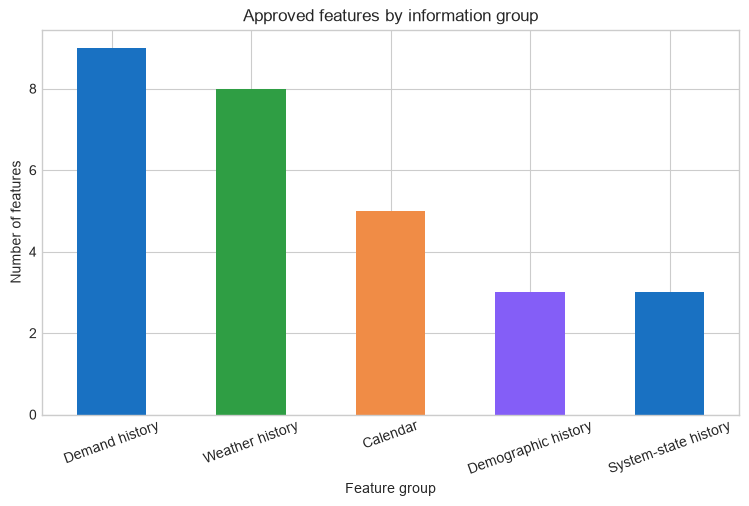

In [4]:
group_counts = inclusion_register.groupby('group').size().sort_values(ascending=False)
display(group_counts.to_frame('feature_count'))
fig, ax = plt.subplots(figsize=(9, 5))
group_counts.plot(kind='bar', ax=ax, color=['#1971c2', '#2f9e44', '#f08c46', '#845ef7'])
ax.set_title('Approved features by information group')
ax.set_xlabel('Feature group')
ax.set_ylabel('Number of features')
ax.tick_params(axis='x', rotation=20)
fig.savefig(FIGURE_DIR / '01_features_by_group.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Raw fields not used directly

Some source fields are deliberately excluded from the predictor matrix. Exclusion does not always mean the information is discarded: observed weather, system-state, and demographic fields are represented through their one-month lag.

In [5]:
excluded_register = pd.DataFrame([
    {'source_field': 'date', 'decision': 'Index only', 'reason': 'Used to create calendar features and preserve order'},
    {'source_field': 'area_id', 'decision': 'Excluded', 'reason': 'Constant identifier; not predictive'},
    {'source_field': 'residential_water_demand_m3', 'decision': 'Target only', 'reason': 'Kept separate from predictors'},
    {'source_field': 'Raw weather fields', 'decision': 'Not used directly', 'reason': 'Lagged by one month to avoid target-month assumptions'},
    {'source_field': 'Raw system-state fields', 'decision': 'Not used directly', 'reason': 'Lagged by one month to avoid target-month assumptions'},
    {'source_field': 'Raw demographic fields', 'decision': 'Not used directly', 'reason': 'Lagged by one month for a conservative forecast-origin rule'},
])
display(excluded_register)

,source_field,decision,reason
0,date,Index only,Used to create calendar features and preserve order
1,area_id,Excluded,Constant identifier; not predictive
2,residential_water_demand_m3,Target only,Kept separate from predictors
3,Raw weather fields,Not used directly,Lagged by one month to avoid target-month assumptions
4,Raw system-state fields,Not used directly,Lagged by one month to avoid target-month assumptions
5,Raw demographic fields,Not used directly,Lagged by one month for a conservative forecast-origin rule


## 5. Why the first 12 months are removed

The longest approved demand history is 12 months. The first year cannot have a complete 12-month history, so those rows are retained for inspection but removed from the complete modelling matrix. No imputation or future-value filling is used.

,missing_rows
demand_lag_12,12
demand_lag_6,6
demand_rolling_std_6,6
demand_rolling_mean_6,6
demand_rolling_std_3,3
demand_lag_3,3
demand_rolling_mean_3,3
demand_lag_2,2
temp_max_c_lag_1,1
rainfall_mm_lag_1,1


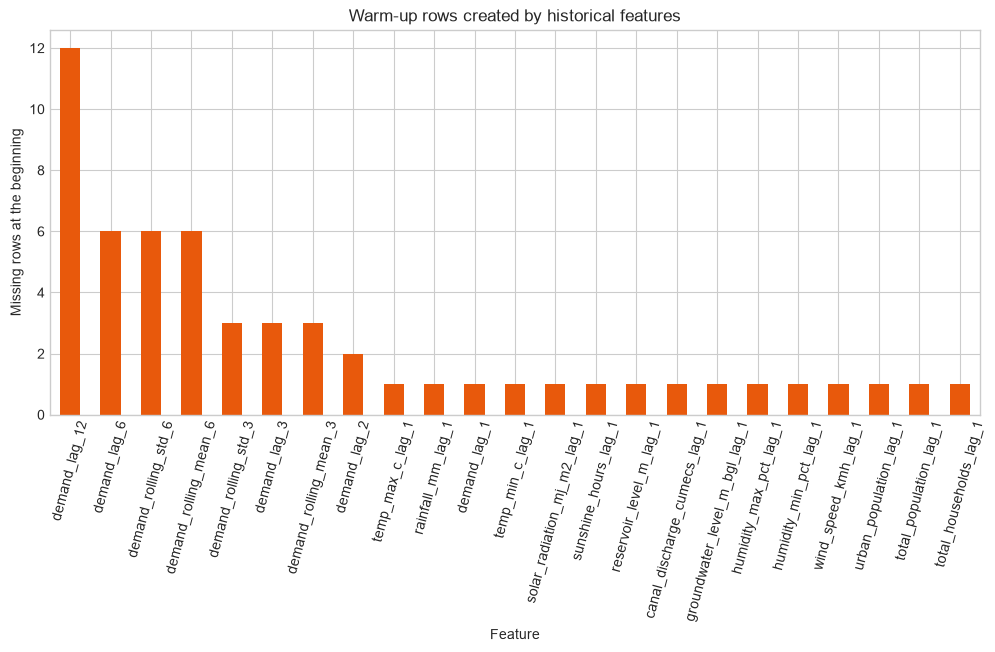

In [6]:
missing_by_feature = features_full.isna().sum().sort_values(ascending=False)
display(missing_by_feature.to_frame('missing_rows').head(12))
fig, ax = plt.subplots(figsize=(12, 5))
missing_by_feature[missing_by_feature > 0].plot(kind='bar', ax=ax, color='#e8590c')
ax.set_title('Warm-up rows created by historical features')
ax.set_xlabel('Feature')
ax.set_ylabel('Missing rows at the beginning')
ax.tick_params(axis='x', rotation=75)
fig.savefig(FIGURE_DIR / '02_warmup_missingness.png', dpi=160, bbox_inches='tight')
plt.show()
assert len(features_ready) == 168
assert features_ready.notna().all().all()

## 6. Descriptive relationships, not automatic selection

This view shows correlations for context only. A high correlation does not by itself prove that a feature should be used, because availability and leakage rules come first.

,correlation_with_demand
demand_lag_12,0.850988
demand_lag_1,0.763911
temp_max_c_lag_1,0.623543
month_sin,0.602470
humidity_max_pct_lag_1,-0.581883
sunshine_hours_lag_1,0.570660
rainfall_mm_lag_1,-0.569360
demand_rolling_mean_3,0.565854
temp_min_c_lag_1,0.541752
humidity_min_pct_lag_1,-0.540438


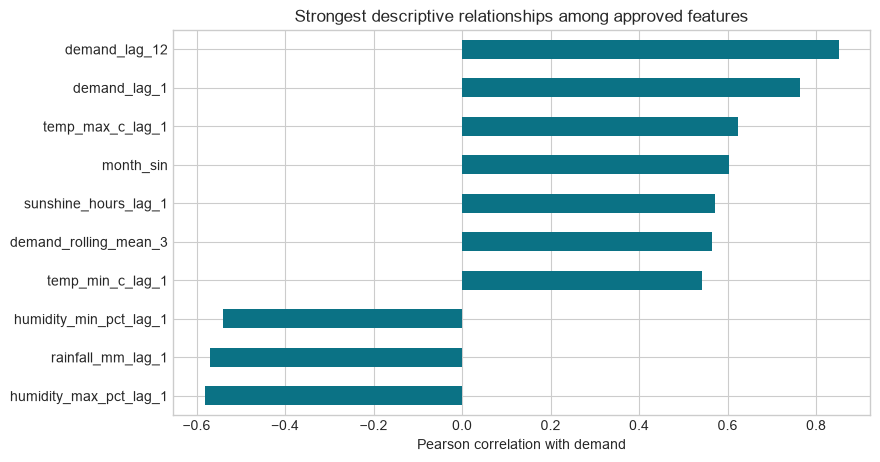

In [7]:
correlations = features_ready.join(target_ready).corr(numeric_only=True)[target.name].drop(target.name).sort_values()
top_relationships = correlations.abs().sort_values(ascending=False).head(10).index
display(correlations.loc[top_relationships].to_frame('correlation_with_demand'))
fig, ax = plt.subplots(figsize=(9, 5))
correlations.loc[top_relationships].sort_values().plot(kind='barh', ax=ax, color='#0b7285')
ax.set_title('Strongest descriptive relationships among approved features')
ax.set_xlabel('Pearson correlation with demand')
fig.savefig(FIGURE_DIR / '03_approved_feature_relationships.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Final review summary

In [8]:
review_summary = {
    'source_rows': int(len(data)),
    'approved_feature_count': int(len(features_ready.columns)),
    'complete_model_rows': int(len(features_ready)),
    'warm_up_rows_removed': int(len(data) - len(features_ready)),
    'target_kept_separately': True,
    'raw_target_month_predictors_used': False,
    'future_value_fill_used': False,
    'review_status': 'COMPLETE',
}
summary_path = REPORT_DIR / 'feature_availability_audit.json'
summary_path.write_text(json.dumps(review_summary, indent=2))
display(pd.Series(review_summary, name='value').to_frame())
print(f'Saved feature review summary to {summary_path}')
assert review_summary['approved_feature_count'] == 28
assert review_summary['complete_model_rows'] == 168
assert review_summary['raw_target_month_predictors_used'] is False

,value
source_rows,180
approved_feature_count,28
complete_model_rows,168
warm_up_rows_removed,12
target_kept_separately,True
raw_target_month_predictors_used,False
future_value_fill_used,False
review_status,COMPLETE


Saved feature review summary to C:\Users\derai\Desktop\ml_based_irrigation\outputs\reports\feature_availability_audit.json


### Plain-language conclusion

We kept information that is either known in advance, such as the calendar, or already observed before the month being predicted. We did not use raw target-month measurements as predictors. The resulting feature set contains 28 approved columns and 168 complete monthly rows after the deterministic 12-month warm-up period.